# 0. Импорт необходимых библиотек

In [1]:
# Импортируем нужные библиотеки

from IPython.display import HTML
import numpy as np
import matplotlib.pyplot as plt

import warnings
 
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

import pysindy as ps
from pysindy.differentiation import SmoothedFiniteDifference
from scipy.integrate import solve_ivp
from scipy.signal import savgol_filter

from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split # класс разбиения на данные для обучения и для проверки
from sklearn.preprocessing import MinMaxScaler


# 1. Базовая задача с ОДУ Лоренца. Генерация искусстревнного массива данных.

In [2]:
# 1.1. Истинная система Лоренца (для генерации данных)
def lorenz_ode(t, state, sigma=10.0, rho=28.0, beta=8/3):
    """
    Правая часть системы обыкновенных дифференциальных уравнений Лоренца.
       
    Параметры:
    ----------
    state : array-like of shape (3,)
            Вектор текущего состояния системы: [x, y, z].
    sigma : float, optional
            Число Прандтля (отношение вязкости к температуропроводности). 
            Классическое значение: 10.0.
    rho : float, optional
            Нормированное число Рэлея (характеризует разность температур). 
            При rho=28 система переходит в хаотический режим.
    beta : float, optional
            Геометрический параметр конвективной ячейки. Классическое значение: 8/3 (~2.667).
        
    Возвращает:
    ----------
    list[float]
        Вектор производных состояния: [dx/dt, dy/dt, dz/dt].
        
    Примечание:
    -----------
    При параметрах (sigma=10, rho=28, beta=8/3) система формирует 
    «странный аттрактор Лоренца» и демонстрирует детерминированный хаос.
    """
    x, y, z = state

    x_dot = sigma * (y - x)
    y_dot = x * (rho - z) - y
    z_dot = x * y - beta * z

   
    return [x_dot, y_dot, z_dot]

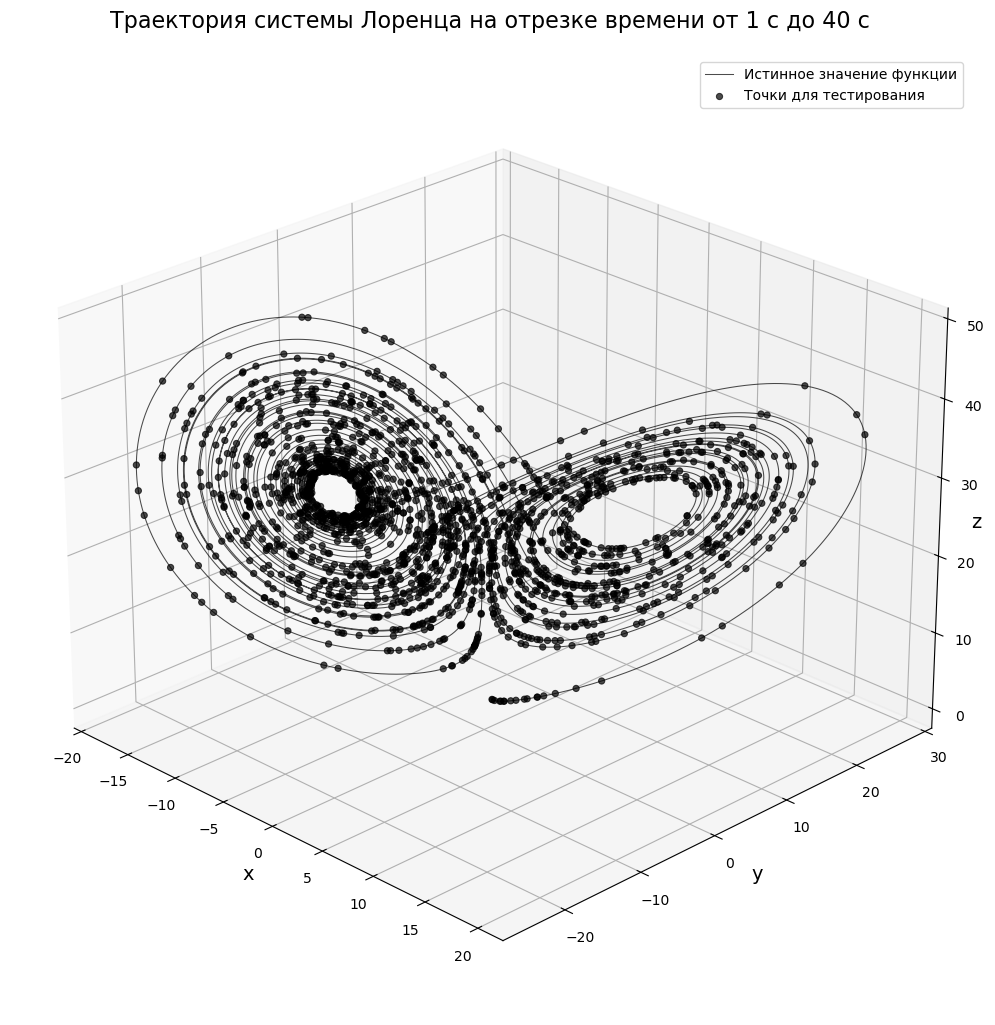

In [3]:
# 1.2. Генерация набора данных
   

# Данные для обучения
dt = 0.002 # шаг по времени
t_start, t_end = (1, 40)


t_train = np.arange(t_start, t_end, dt) # дискретизация промежутка времени

t_span = (t_start, t_end) # промежуток времени

x0 = [0., 1., 1.05] # начальные условия

# Точное интегрирование
sol = solve_ivp(
    lorenz_ode, 
    t_span, # отрезок по времени
    x0, # начальные условия
    t_eval=t_train, # массив времени 
    args=(10.0, 28.0, 8/3), # коэффициенты sigma=10.0, rho=28.0, beta=8/3
    rtol=1e-8,  # Относительная точность
    atol=1e-10, # Абсолютная точность
    method='RK45'
)

# Формируем массив данных (n_samples, n_features)
X_train = sol.y.T

# Данные для тестирования
# массив времени
t_test = np.random.uniform(t_start, t_end, int(len(t_train) * 0.1) )
t_test = np.sort(t_test)
# интегрируем
sol = solve_ivp(
    lorenz_ode, 
    t_span, # отрезок по времени
    x0, # начальные условия
    t_eval= t_test , # массив времени 
    args=(10.0, 28.0, 8/3), # коэффициенты sigma=10.0, rho=28.0, beta=8/3
    rtol=1e-8,  # Относительная точность
    atol=1e-10, # Абсолютная точность
    method='RK45')
X_test = sol.y.T






# 1.3. Визуализируем данные
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(X_train[:,0], X_train[:,1], X_train[:,2], lw=0.75, color='black', alpha=0.7, label='Истинное значение функции')
ax.scatter (X_test[:,0], X_test[:,1], X_test[:,2], lw=0.75, color='black', alpha=0.7, label='Точки для тестирования')

elev = 25
azim = -45
ax.view_init(elev=elev, azim=azim)

ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14, labelpad = -6)

ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'Траектория системы Лоренца на отрезке времени от {t_train[0]:.0f} с до {t_train[-1]:.0f} с', fontsize=16, pad=20)


plt.subplots_adjust(left=-0.1, right=1.3, bottom=-0.1, top=1.1)

plt.show()

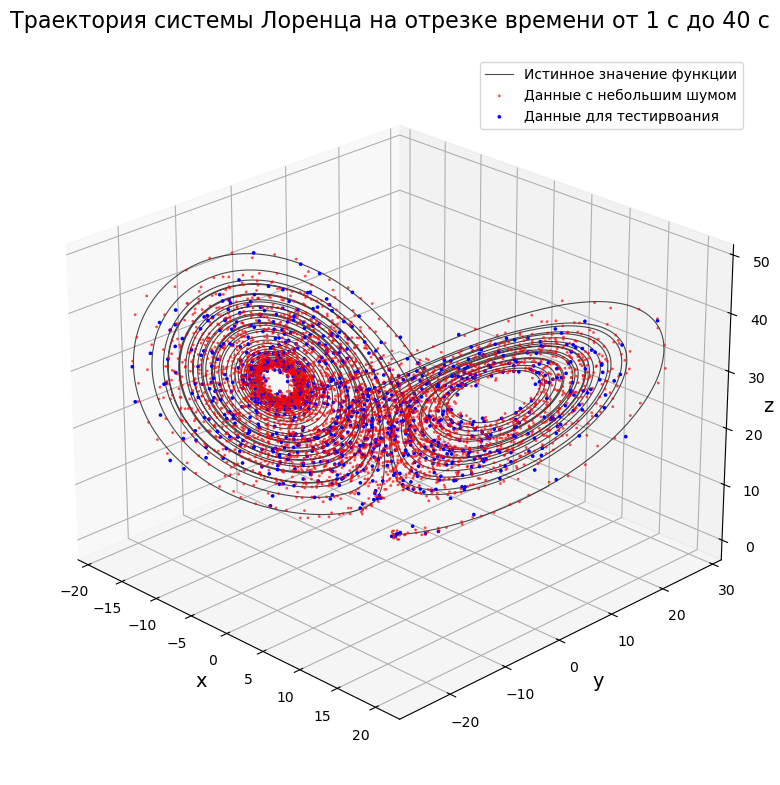

In [4]:
# 1.4. Генерация набора данных с шумом
noise_level = 0.05  # 5% шума относительно std каждой переменной

# Вычисляем std для каждой колонки (x, y, z) отдельно
std_per_feature = np.std(X_train, axis=0)  # массив из 3 значений
# Генерируем шум для каждой переменной
noise = noise_level * std_per_feature * np.random.randn(*X_train.shape)
# Добавляем шум
X_train_noisy = X_train + noise

# то же самое, только для данных для тестирвоания
std_per_feature = np.std(X_test, axis=0)
noise = noise_level * std_per_feature * np.random.randn(*X_test.shape)
X_test_noisy = X_test + noise





# 1.5. Визуализируем данные
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Исходная линия
ax.plot(X_train[:,0], X_train[:,1], X_train[:,2], lw=0.8, color='black', alpha=0.7, label='Истинное значение функции')

# Зашумлённые точки с прозрачностью по плотности
step = 5
ax.scatter(X_train_noisy[:,0][::step],X_train_noisy[:,1][::step], X_train_noisy[:,2][::step], 
           c='red', s=4, alpha=0.7, edgecolors='none', label='Данные с небольшим шумом')
step = 2
ax.scatter(X_test_noisy[:,0][::step],X_test_noisy[:,1][::step], X_test_noisy[:,2][::step], 
           c='blue', s=7, alpha=1, edgecolors='none', label='Данные для тестирвоания')



ax.view_init(elev=25, azim=-45)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14, labelpad = -4)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'Траектория системы Лоренца на отрезке времени от {t_train[0]:.0f} с до {t_train[-1]:.0f} с', fontsize=16, pad=20)
plt.subplots_adjust(left=0.05, right=0.85, bottom=0.05, top=0.95)
plt.show()

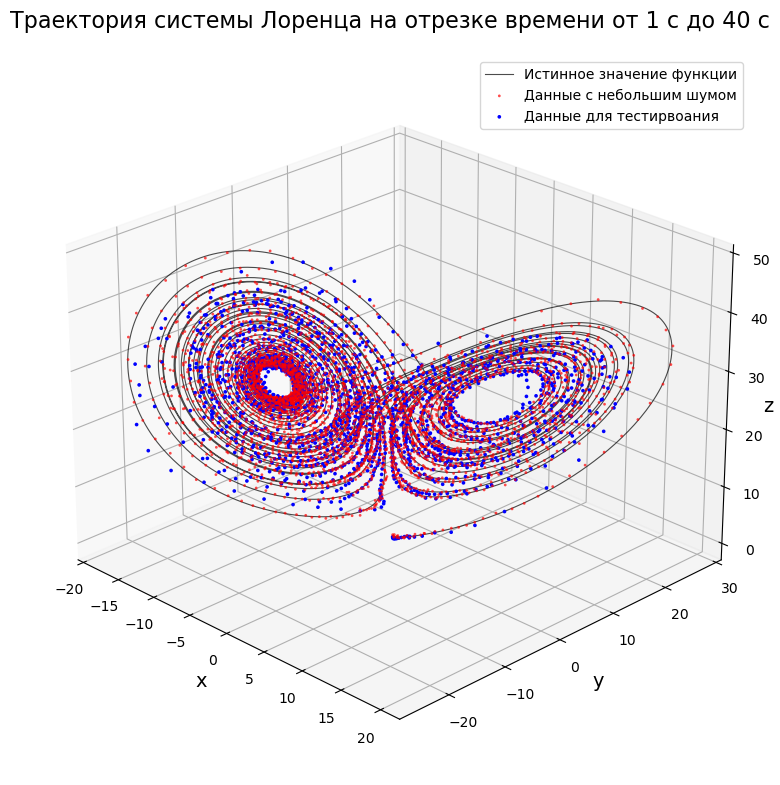

In [5]:
# 1.6. Сгладим зашумленные данные
X_train_smoothed = savgol_filter(X_train_noisy, window_length=15, polyorder=3, axis=0)
X_test_smoothed = savgol_filter(X_test_noisy, window_length=15, polyorder=3, axis=0)

# 1.7. Визуализируем данные
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Исходная линия
ax.plot(X_train[:,0], X_train[:,1], X_train[:,2], lw=0.8, color='black', alpha=0.7, label='Истинное значение функции')

# Зашумлённые точки с прозрачностью по плотности
step = 5
ax.scatter(X_train_smoothed[:,0][::step],X_train_smoothed[:,1][::step], X_train_smoothed[:,2][::step], 
           c='red', s=4, alpha=0.7, edgecolors='none', label='Данные с небольшим шумом')
step = 1
ax.scatter(X_test_smoothed[:,0][::step],X_test_smoothed[:,1][::step], X_test_smoothed[:,2][::step], 
           c='blue', s=7, alpha=1, edgecolors='none', label='Данные для тестирвоания')


ax.view_init(elev=25, azim=-45)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel('y', fontsize=14)
ax.set_zlabel('z', fontsize=14, labelpad = -4)
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_title(f'Траектория системы Лоренца на отрезке времени от {t_train[0]:.0f} с до {t_train[-1]:.0f} с', fontsize=16, pad=20)
plt.subplots_adjust(left=0.05, right=0.85, bottom=0.05, top=0.95)
plt.show()

# 2. Базовая задача с ОДУ Лоренца. Поиск коэффициентов уравнения по данным из незашумленныго масива x, y, z, t
## 2.0. Поиск искомого уравнения

In [55]:
# 2.0.0. Попытка найки коэффициенты уравнения с помощью обыкновенного нормального уравения (threshold=0.0)
feature_names = ['x', 'y', 'z']
opt = ps.STLSQ(threshold=0.0)
model = ps.SINDy(optimizer = opt)
model.fit(X_train, t=t_train, feature_names = feature_names)
model.print()
print (f'R² = {model.score(X_test, t=t_test):.5f}')

(x)' = -10.003 x +  10.002 y
(y)' =  0.010 1 +  27.991 x + -0.998 y + -0.001 z + -1.000 x z
(z)' = -0.010 1 + -0.001 x +  0.001 y + -2.664 z +  0.001 x^2 +  0.999 x y
R² = 0.99860


In [56]:
# 2.0.1. Вторая попытка найки коэффициенты уравнения (уже с настройкой threshold)
opt = ps.STLSQ(threshold=0.1)
model = ps.SINDy(optimizer = opt)
model.fit(X_train, t=t_train, feature_names = feature_names)
model.print()
print (f'R² = {model.score(X_test, t=t_test):.5f}')

(x)' = -9.999 x +  9.999 y
(y)' =  27.992 x + -0.998 y + -1.000 x z
(z)' = -2.666 z +  1.000 x y
R² = 0.99859


# 3. Базовая задача с ОДУ Лоренца. Поиск коэффициентов уравнения по зашумленным данным

In [57]:
# 3.0. То же самое, что и 2.1., только с зашумленными данными
opt = ps.STLSQ(threshold=0.1)
model = ps.SINDy(optimizer = opt)
model.fit(X_train_noisy, t=t_train, feature_names = feature_names)
model.print()
print (f'R² = {model.score(X_test_noisy, t_test, metric = r2_score):.5f}')

(x)' = -9.727 x +  9.746 y
(y)' = -0.358 1 +  25.420 x + -0.947 x z
(z)' = -2.648 z +  0.994 x y
R² = -0.00089


In [61]:
# 3.1. Попробуем более тонко настроить вид функции, в частности возьмем полином и отключим у него свободный член
opt = ps.STLSQ(threshold=0.1, alpha=0.01, normalize_columns=False)
model = ps.SINDy(optimizer = opt, feature_library = ps.PolynomialLibrary(degree=2, include_bias=False))
model.fit(X_train_noisy, t=dt, feature_names = feature_names)
model.print()
print (f'R² = {model.score(X_test_noisy, t=t_test, metric = r2_score):.5f}')

(x)' = -9.727 x +  9.746 y
(y)' =  25.448 x + -0.947 x z
(z)' = -2.648 z +  0.994 x y
R² = -0.00089


# 4. Автоматический поиск коэффициентов уравнения.
## 4.0. Незашумленные данные

In [11]:

# 4.0.0. Функция для перебора threshold
def tune_sindy_threshold(X_train, t_train, X_test, t_test, threshold_scan, feature_names, degree=2):
    """
    Автоматический подбор параметра threshold для оптимизатора STLSQ в PySINDy.
    
    Параметры:
    ----------
    X_train : array-like of shape (n_samples, n_features)
        Матрица состояний системы.
    dt : float
        Шаг интегрирования/дискретизации по времени.
    threshold_scan : array-like, optional
        Массив значений threshold для перебора. По умолчанию: np.arange(0.01, 0.5, 0.01)
    feature_names : list of str, optional
        Имена переменных. По умолчанию: ['x', 'y', 'z']
    degree : int, optional
        Степень полиномиальной библиотеки. По умолчанию: 2
            
    Возвращает:
    -----------
    dict : {'best_model', 'best_threshold', 'best_idx', 'mse_scores', 'r2_scores', 'threshold_scan'}
    """

    mse_scores = np.zeros(len(threshold_scan))
    r2_scores = np.zeros(len(threshold_scan))
    best_idx = 0
    min_mse = np.inf
    best_model = None

    # Вычисляем производные один раз для всех итераций
    sfd = SmoothedFiniteDifference(smoother_kws={'window_length': 5})
    X_dot_train_true = sfd._differentiate(X_train, t_train)
    X_dot_test_true = sfd._differentiate(X_test, t_test)
    
    
  
    # Подавляем предупреждения PySINDy только внутри цикла
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        
        for i, thr in enumerate(threshold_scan):
            opt = ps.STLSQ(threshold=thr, max_iter=100, normalize_columns=False)
            model = ps.SINDy(
                optimizer=opt,
                feature_library=ps.PolynomialLibrary(degree=degree, include_bias=False)
            )
            
            model.fit(X_train, t=t_train, x_dot=X_dot_train_true, feature_names=feature_names)
            model.score(X_test, t_test)
            
            #X_dot_pred = model.predict(X_test)
            
            #mse_scores[i] = mean_squared_error(X_dot_test_true, X_dot_pred, multioutput='uniform_average')
            #r2_scores[i] = r2_score(X_dot_test_true, X_dot_pred, multioutput='uniform_average')
            
            if mse_scores[i] < min_mse:
                min_mse = mse_scores[i]
                best_idx = i
                best_model = model

    best_threshold = threshold_scan[best_idx]

    return {
        'best_model': best_model,
        'threshold_list': threshold_scan,
        'best_idx': best_idx,
        'mse_scores': mse_scores,
        'r2_scores': r2_scores,
         }





# 4.0.0. Пробуем с незашумленными данными
# Вызов функции 
results = tune_sindy_threshold(X_train, t_train,
                               X_test, t_test,
                               threshold_scan = np.arange (2., 0.01, -0.01),
                              feature_names = feature_names,
                              degree=2)

# Распаковка результатов
best_model = results['best_model']
best_idx   = results['best_idx']

best_thr   = results['threshold_list'][best_idx]
mse_vals   = results['mse_scores']
r2_vals    = results['r2_scores']
thresholds = results['threshold_list']


print(f"Лучший threshold: {best_thr:.4f}")
print (f"Средняя абсолютная ошибка: {mse_vals[best_idx]:.4f}")
print (f"Коэффициент детерминации: {r2_vals[best_idx]:.4f}")
print ('Модель:')
best_model.print()


Лучший threshold: 0.9900
Средняя абсолютная ошибка: 3185983.4953
Коэффициент детерминации: 0.0153
Модель:
(x)' = -9.999 x +  9.999 y
(y)' =  27.992 x + -0.998 y + -1.000 x z
(z)' = -2.666 z +  1.000 x y


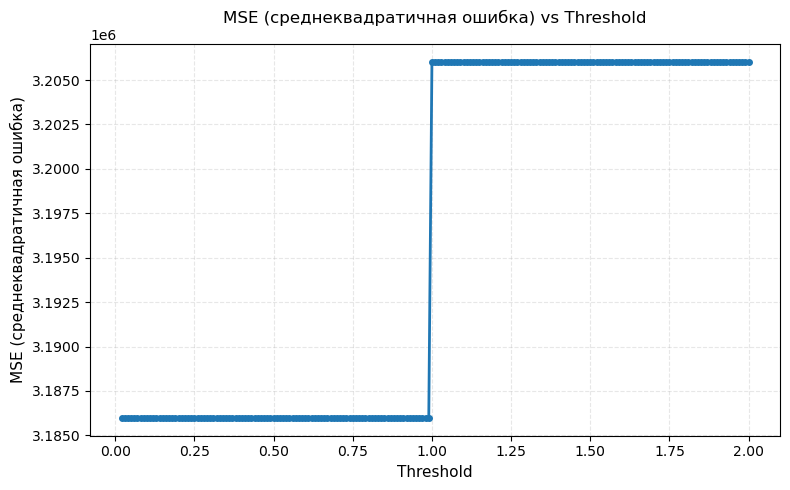

In [12]:
# 4.0.1. Визуализируем перебор thresholds
def plot_sindy_metric(results, metric='r2', xscale='log', figsize=(8, 5), show_best=True):
    """
    Строит график зависимости ОДНОЙ метрики (R² или MSE) от threshold.
    
    Параметры:
    ----------
    results : dict
        Словарь из tune_sindy_threshold с ключами:
        'threshold_list', 'mse_scores', 'r2_scores', 'best_idx'
    metric : str
        'r2' — построить график R²
        'mse' — построить график MSE
    xscale : str
        'log' — логарифмическая шкала по X (рекомендуется для threshold)
        'linear' — линейная шкала
    figsize : tuple
        Размер фигуры (ширина, высота)
    show_best : bool
        Отмечать ли лучшую точку маркером
        
    Возвращает:
    -----------
    fig, ax : объекты matplotlib
    """

    # Распаковка результатов
    best_model = results['best_model']
    best_idx   = results['best_idx']
    
    best_thr   = results['threshold_list'][best_idx]
    mse_vals   = results['mse_scores']
    r2_vals    = results['r2_scores']
    thresholds = results['threshold_list']
  
    
    # Выбираем данные в зависимости от метрики
    if metric == 'r2':
        values = results['r2_scores']
        ylabel = 'R² (коэффициент детерминации)'
        

        r2_min = min(r2_vals)
        r2_max = max(r2_vals)
        #y_lim = [r2_min*0.9, r2_max*1.1]  
    elif metric == 'mse':
        values = results['mse_scores']
        ylabel = 'MSE (среднеквадратичная ошибка)'
        y_lim = None  # Автомасштаб для MSE, т.к. диапазон может быть любым
    else:
        raise ValueError("metric должен быть 'r2' или 'mse'")
    
    # Создаём график
    fig, ax = plt.subplots(figsize=figsize)
    
    # Выбор шкалы и построение
    if xscale == 'log':
        ax.semilogx(thresholds, values, linewidth=2, marker='o', markersize=4)
    else:
        ax.plot(thresholds, values, linewidth=2, marker='o', markersize=4)
    
    # Оформление осей
    ax.set_xlabel('Threshold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.tick_params(axis='y')
    ax.grid(True, alpha=0.3, linestyle='--')
     
      
    # Заголовок и легенда
    ax.set_title(f'{ylabel} vs Threshold', fontsize=12, pad=15)
       
    plt.tight_layout()

plot_sindy_metric(results, metric='mse', xscale='linear', figsize=(8, 5), show_best=True)



## 4.1. Зашумленные данные

In [13]:
# 4.1.0. Пробуем с зашумленными данными
# Вызов функции 
results = tune_sindy_threshold(X_train_noisy, t_train,
                               X_test, t_test,
                               threshold_scan = np.arange (2., 0.01, -0.01),
                              feature_names = feature_names,
                              degree=2)

# Распаковка результатов
best_model = results['best_model']
best_idx   = results['best_idx']

best_thr   = results['threshold_list'][best_idx]
mse_vals   = results['mse_scores']
r2_vals    = results['r2_scores']
thresholds = results['threshold_list']

print(f"Лучший threshold: {best_thr:.4f}")
print (f"Средняя абсолютная ошибка: {mse_vals[best_idx]:.4f}")
print (f"Коэффициент детерминации: {r2_vals[best_idx]:.4f}")
print ('Модель:')
best_model.print()

Лучший threshold: 0.9400
Средняя абсолютная ошибка: 3186140.3331
Коэффициент детерминации: 0.0151
Модель:
(x)' = -9.742 x +  9.761 y
(y)' =  25.484 x + -0.949 x z
(z)' = -2.648 z +  0.994 x y


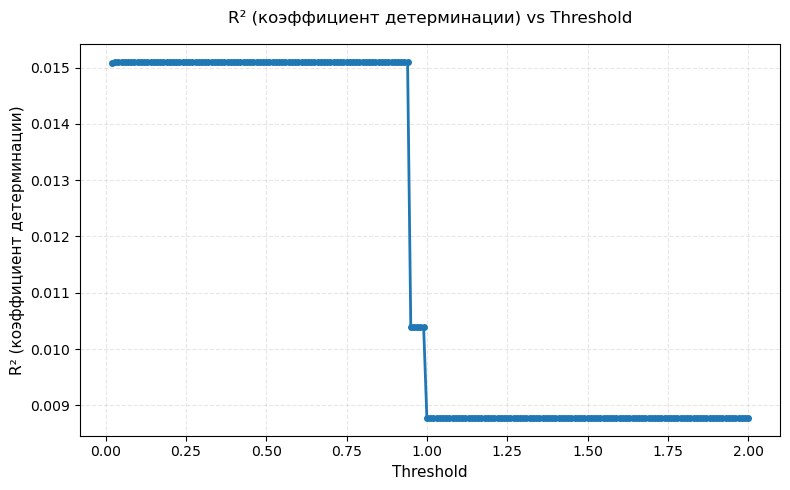

In [14]:
# 4.1.1. Визуализируем перебор thresholds
plot_sindy_metric(results, metric='r2', xscale='linear', figsize=(8, 5), show_best=True)

## 4.2. Сглаженные данные

In [15]:
# 4.2.0. Пробуем с зашумленными данными
# Вызов функции 
results = tune_sindy_threshold(X_train_smoothed, t_train,
                               X_test, t_test,
                               threshold_scan = np.arange (2., 0.01, -0.01),
                              feature_names = feature_names,
                              degree=2)

# Распаковка результатов
# Распаковка результатов
best_model = results['best_model']
best_idx   = results['best_idx']

best_thr   = results['threshold_list'][best_idx]
mse_vals   = results['mse_scores']
r2_vals    = results['r2_scores']
thresholds = results['threshold_list']

print(f"Лучший threshold: {best_thr:.4f}")
print (f"Средняя абсолютная ошибка: {mse_vals[best_idx]:.4f}")
print (f"Коэффициент детерминации: {r2_vals[best_idx]:.4f}")
print ('Модель:')
best_model.print()

Лучший threshold: 0.9500
Средняя абсолютная ошибка: 3185988.5973
Коэффициент детерминации: 0.0153
Модель:
(x)' = -9.942 x +  9.942 y
(y)' =  25.658 x + -0.954 x z
(z)' = -2.662 z +  0.999 x y


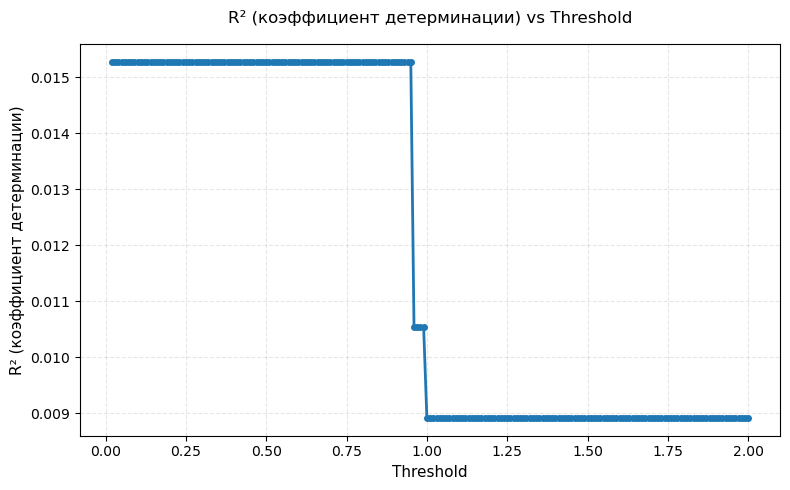

In [16]:
# 4.2.1. Визуализируем перебор thresholds
plot_sindy_metric(results, metric='r2', xscale='linear', figsize=(8, 5), show_best=True)

In [17]:
model.simulate(X_test[0, :], t_test, integrator="odeint")

array([[  0.05793369,   0.99874684,   1.0335717 ],
       [  0.11126895,   1.01109788,   1.01791366],
       [  0.25270001,   1.08659083,   0.97665648],
       ...,
       [-11.66484683, -13.6046225 ,  28.99836527],
       [-11.71781047, -13.53336077,  29.22861282],
       [-11.97166279, -12.8876797 ,  30.65278721]], shape=(1950, 3))

In [18]:
X_test[0, :]

array([0.05793369, 0.99874684, 1.0335717 ])

In [19]:
t_test.shape

(1950,)

In [23]:
model.score(X_test, t_test, metric = r2_score)


0.9980852206398021

In [51]:
dt

0.002